# OpenBind-HIPPO

- **Target: A71EV2A**
- **Cycle: 01**

## Imports

In [5]:
%load_ext autoreload
%autoreload 2
import hippo
import mrich
from mrich import print
from pathlib import Path
from os import environ
import shutil
import molparse as mp
import pandas as pd
import plotly.express as px

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Config

In [6]:
target_name = "A71EV2A"
target_dir = Path(environ["BULK"]) / "TARGETS" / target_name
cycle_name = "cycle_01"
cycle_dir = Path(cycle_name)
aligned_dir = target_dir / "aligned_files"

## Animal

In [17]:
animal = hippo.HIPPO(target_name, target_dir / f"{target_name}.sqlite",
                    copy_from="/opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A_1GDPR8P.sqlite", 
                    overwrite_existing=True,
)

 Creating HIPPO animal

name = A71EV2A

db_path = /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A.sqlite

 Warning  Overwriting /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A.sqlite!

Copying /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A_1GDPR8P.sqlite --> 
/opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A.sqlite

...

DEBUG: Database.path = /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A.sqlite

DEBUG: hippo.Database.connect()

DEBUG: sqlite3.version='2.6.0'

 Success  Database connected @ /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A.sqlite!

 Success  Initialised animal HIPPO("A71EV2A")!

## Check Elabs

In [8]:
elab_dir = Path("cycle_01/syndirella/elabs")

In [9]:
dfs = []
files = list(elab_dir.glob("*/*output*.csv"))
mrich.var("#CSVs", len(files))
for file in files:
    df = pd.read_csv(file)
    dfs.append(df)

#CSVs = 492

In [10]:
df = pd.concat(dfs)
df.to_csv(elab_dir / "summary.csv")

In [16]:
counts = (
    df[["error_type", "error_message"]]
    .dropna(subset=["error_type"])
    .value_counts()
    .reset_index(name="count")
)
with open(elab_dir / "errors.csv", "wt") as f:
    for _, row in counts.iterrows():
        f.write(f"{row['error_type']},{row['error_message']},{row['count']}\n")

In [11]:
df.head()

,smiles,inchi_key,error_type,error_message,retro_tool,db_search_tool,1_r1_smiles,1_r2_smiles,1_reaction,compound_set,...,num_successful,route_uuid,template,to_hippo,total_num_products_enumstereo,total_num_unique_products,hit3,hit4,hit5,hit6
0,CCCS(=O)(=O)NC1CCN(C(=O)[C@@H](F)n2cccn2)CC1,OEOUTLNRPVGOPE-UHFFFAOYSA-N,NaN,NaN,aizynthfinder,hippo,CCCS(=O)(=O)NC1CCNCC1,O=C(O)C(F)n1cccn1,Amidation,C12352,...,0.0,c0b57bd6ea349f9ef3ed11c430c3112d,/opt/xchem-fragalysis-2/maxwin/openbind-hippo/...,/opt/xchem-fragalysis-2/maxwin/openbind-hippo/...,24.0,6.0,NaN,NaN,NaN,NaN
0,CC(C)(NC(=O)[C@H]1CCNc2ccccc21)C1CCNCC1,XIOYKRXGPYNPFZ-UHFFFAOYSA-N,NaN,NaN,aizynthfinder,hippo,O=C(O)C1CCNc2ccccc21,CC(C)(N)C1CCNCC1,Amidation,C124015,...,0.0,1391d0ac6455e48996b5571dd92dc0f1,/opt/xchem-fragalysis-2/maxwin/openbind-hippo/...,/opt/xchem-fragalysis-2/maxwin/openbind-hippo/...,1574.0,344.0,NaN,NaN,NaN,NaN
0,C[C@H](C(=O)N1CCC(OCCCN(C)C)CC1)[C@@H]1CCC(=O)N1,MQHOJDGABPALRL-UHFFFAOYSA-N,OSError,File error: Bad input file /opt/xchem-fragalys...,NaN,NaN,NaN,NaN,NaN,C9987,...,NaN,NaN,/opt/xchem-fragalysis-2/maxwin/openbind-hippo/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C[C@H](C(=O)N1CCC(OCCCN(C)C)CC1)[C@@H]1CCC(=O)N1,MQHOJDGABPALRL-UHFFFAOYSA-N,OSError,File error: Bad input file /opt/xchem-fragalys...,NaN,NaN,NaN,NaN,NaN,C9987,...,NaN,NaN,/opt/xchem-fragalysis-2/maxwin/openbind-hippo/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C[C@H](C(=O)N1CCC(OCCCN(C)C)CC1)[C@@H]1CCC(=O)N1,MQHOJDGABPALRL-UHFFFAOYSA-N,ScaffoldPlacementError,Scaffold could not be successfully placed.,NaN,NaN,NaN,NaN,NaN,C9987,...,NaN,NaN,/opt/xchem-fragalysis-2/maxwin/openbind-hippo/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
counts = (
    df[["error_type", "error_message"]]
    .dropna(subset=["error_type"])
    .value_counts()
    .reset_index(name="count")
)

with open(elab_dir / "errors.csv", "w") as f:
    for _, row in counts.iterrows():
        f.write(f"{row['error_type']},{row['error_message']},{row['count']}\n")

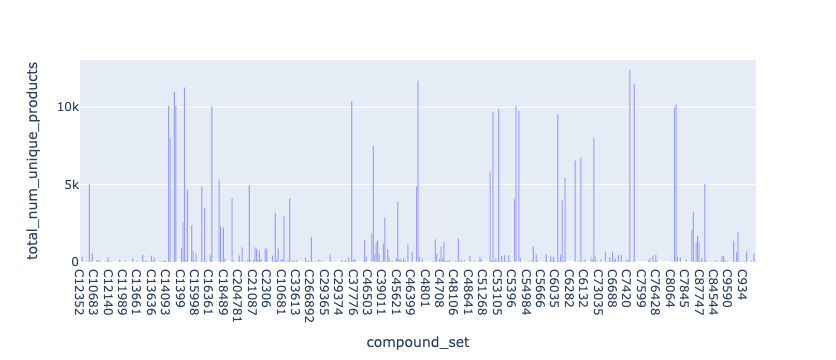

In [14]:
px.bar(df, x="compound_set", y="total_num_unique_products")

In [15]:
pickles = list(elab_dir.glob("*/*/*to_hippo.pkl.gz"))
[p.name for p in pickles]

['OEOUTLNRPVGOPE-UHFFFAOYSA-N_c0b57bd6ea349f9ef3ed11c430c3112d_to_hippo.pkl.gz',
 'XIOYKRXGPYNPFZ-UHFFFAOYSA-N_1391d0ac6455e48996b5571dd92dc0f1_to_hippo.pkl.gz',
 'MQHOJDGABPALRL-UHFFFAOYSA-N_5cbb1718d952b7295d9b447c94356cfa_to_hippo.pkl.gz',
 'JWMDCIUJPJCIMA-UHFFFAOYSA-N_5f42d96aaf8d702f57e76b28123239ca_to_hippo.pkl.gz',
 'MRPNTPLWNNFLQF-UHFFFAOYSA-N_d6767432d8ec88855c9795332c69a501_to_hippo.pkl.gz',
 'MLNMURZXNDQHPB-UHFFFAOYSA-N_0fac5e51dba9d957711be5854f6be0f3_to_hippo.pkl.gz',
 'OTLOOYMQZJZQNU-UHFFFAOYSA-N_49e36e6a83557c9a7a522ebe06efae1b_to_hippo.pkl.gz',
 'XZXXEYWXKJBZSC-UHFFFAOYSA-N_7946426391ce9818d3a73128658b9e05_to_hippo.pkl.gz',
 'MZJWMOJDYRPWCV-UHFFFAOYSA-N_1c8236e61add637529f5ff6707074846_to_hippo.pkl.gz',
 'OVGXOABIOXLLGL-UHFFFAOYSA-N_b7f857bdbd2991eb2369e27caec076c6_to_hippo.pkl.gz',
 'PCPXIHBDOBZPNO-UHFFFAOYSA-N_63853b6417d3b0251ca6018e099437a7_to_hippo.pkl.gz',
 'ONGQCMNCDUWDOR-UHFFFAOYSA-N_329a92254f48aadc4542b887809c6b0c_to_hippo.pkl.gz',
 'RZWXIWQSDZYYOP-UHFFFAOYSA-

In [ ]:
df = pd.read_pickle(pickles[0])
# df.head()
print(df.iloc[0])
list(df.iloc[0].keys())

In [ ]:
df = pd.read_pickle("cycle_01/syndirella/elabs/c01_elabs_C15735_syndirella_input/HDCUDRUHFXHSNY-UHFFFAOYSA-N/HDCUDRUHFXHSNY-UHFFFAOYSA-N_HpCsah_to_hippo.pkl.gz")
df.head()
list(df.iloc[0].keys())

In [18]:
animal.db.backup()

 DISK  Writing /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A_1GE8WZ3.sqlite...

Output()

DEBUG: Copied 10000 of 617667 pages...

DEBUG: Copied 20000 of 617667 pages...

DEBUG: Copied 30000 of 617667 pages...

...

DEBUG: Copied 580000 of 617667 pages...

DEBUG: Copied 590000 of 617667 pages...

DEBUG: Copied 600000 of 617667 pages...

DEBUG: Copied 610000 of 617667 pages...

DEBUG: Copied 617667 of 617667 pages...

In [19]:
%%time
animal.db.fix_incorrect_pose_compound_assignments()

Output()

[08:46:40] SMILES Parse Error: syntax error while parsing: CCC[SOH](=O)(=O)Nc1cccc(C(=O)NCCc2ccon2)c1

[08:46:40] SMILES Parse Error: check for mistakes around position 6:

[08:46:40] CCC[SOH](=O)(=O)Nc1cccc(C(=O)NCCc2ccon2)c

[08:46:40] ~~~~~^

...

[08:50:03] ~~~~~~~~~~~~~~^

[08:50:03] SMILES Parse Error: Failed parsing SMILES 'CN1CC[CH](CN[SOH](=O)(=O)c2cccc3c2CCN3)CC1=O' for input: 
'CN1CC[CH](CN[SOH](=O)(=O)c2cccc3c2CCN3)CC1=O'

 ERROR  Could not sanitise 485443 CN1CC[C@@H](CN[S@OH](=O)(=O)c2cccc3c2CCN3)CC1=O!

#fix = 510

CPU times: user 3min 27s, sys: 1.26 s, total: 3min 28s
Wall time: 3min 34s
